Utilização do *Dataset* do projeto +BIKE, para o estudo de informações estatística.

In [2]:
import pandas as pd

df = pd.read_csv('http://dl.dropboxusercontent.com/s/yyfeoxqw61o3iel/df_rides.csv')

In [3]:
df.head()

,user_gender,user_birthdate,user_residence,ride_date,time_start,time_end,station_start,station_end,ride_duration,ride_late
0,M,1971-06-08,NaN,2018-01-01,06:05:18,06:21:33,11 - Rodoviária 2,41 - Instituto de Artes,16.250000,0.0
1,M,1989-02-11,DF,2018-01-01,06:27:01,06:32:17,26 - Ministério da Saude,28 - CNMP - Conselho Nacional do Ministério Pú...,5.266667,0.0
2,M,1968-07-19,NaN,2018-01-01,06:29:33,06:44:57,11 - Rodoviária 2,43 - Biblioteca Central,15.400000,0.0
3,M,1991-12-19,NaN,2018-01-01,06:53:53,06:59:45,10 - Ministério dos Transportes,6 - Rodoviária,5.866667,0.0
4,M,1969-03-03,DF,2018-01-01,06:58:56,17:40:04,15 - Brasil 21,11 - Rodoviária 2,641.133333,1.0


In [5]:
df.describe()


,ride_duration,ride_late
count,214148.000000,214148.000000
mean,29.915932,0.098829
std,58.857297,0.298433
min,3.000000,0.000000
25%,8.083333,0.000000
50%,14.200000,0.000000
75%,33.766667,0.000000
max,999.600000,1.000000


Com essa função, consigo identificar informações como o tempo médio de duração das corridas em minutos. Consigo ver que o mínimo dessas corridas foi de 3 min e o máximo de 999,6 min, algo em torno de 16 horas, o que torna esse valor um provável outlier. Também é possível observar um desvio padrão alto, indicando valores dispersos em relação à média, o que demonstra a necessidade de aprofundar o estudo do caso

In [6]:
df.ride_duration.mean()

np.float64(29.915931894453053)

In [7]:
df.ride_duration.std()

58.85729654164017

In [9]:
df.ride_duration.max()

999.6

In [10]:
df.ride_duration.min()

3.0

Para visualizar melhor o desvio padrão e a média, vou plotar um histograma importando a biblioteca matplotlib.pyplot.

In [20]:
import matplotlib.pyplot as plt


In [12]:
media = df.ride_duration.mean()

In [13]:
desvio_padrao = df.ride_duration.std()

Com as variaveis criadas posso apenas plotar o histograma

Plotando o histograma

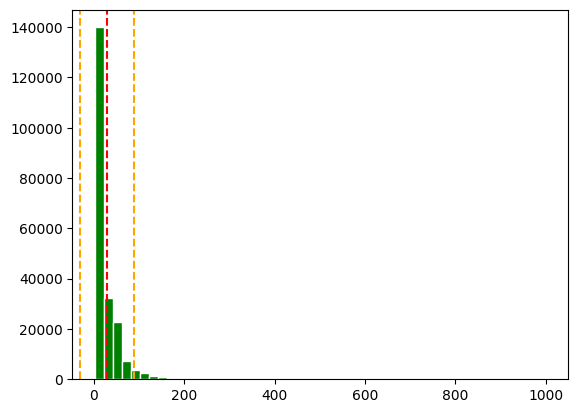

In [29]:
plt.hist(df.ride_duration, bins = 50, color = 'green', edgecolor = 'white')

plt.axvline(media, color = 'red', linestyle = '--', label = f'Média {media:.2f}min')
plt.axvline(media - desvio_padrao, color='orange', linestyle='--', label='Média - 1 desvio padrão')
plt.axvline(media + desvio_padrao, color='orange', linestyle='--', label='Média + 1 desvio padrão')

Para reduzir o impacto dos outliers dei um limite de 0-200min para que a fique mais visivel o gráfico

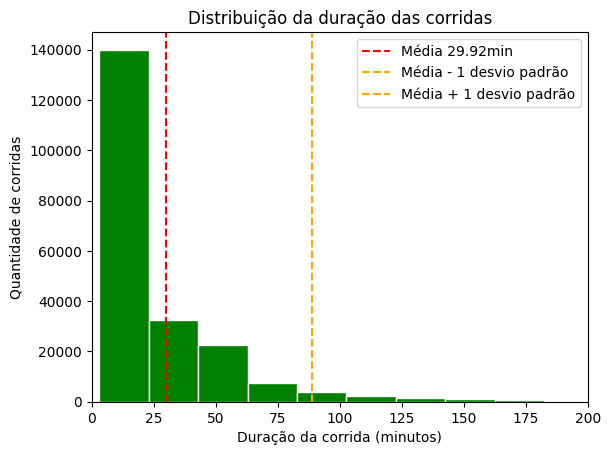

In [28]:
plt.hist(df.ride_duration, bins = 50, color = 'green', edgecolor = 'white')

plt.axvline(media, color = 'red', linestyle = '--', label = f'Média {media:.2f}min')
plt.axvline(media - desvio_padrao, color='orange', linestyle='--', label='Média - 1 desvio padrão')
plt.axvline(media + desvio_padrao, color='orange', linestyle='--', label='Média + 1 desvio padrão')

plt.xlim(0, 200)
plt.xlabel('Duração da corrida (minutos)')
plt.ylabel('Quantidade de corridas')
plt.title('Distribuição da duração das corridas')
plt.legend()
plt.show()

No gráfico, podemos observar que a linha laranja representa a média acrescida de um desvio padrão, com valor aproximado de 89 minutos. Esse valor indica o limite superior de um desvio padrão acima da média. Entretanto, não é possível afirmar, apenas com base no gráfico, que a maioria das corridas esteja dentro desse intervalo.

No entanto, também observamos uma distribuição concentrada à esquerda, com uma cauda alongada à direita. Isso indica que a maioria das corridas dura menos de 30 minutos, enquanto uma parcela menor apresenta durações muito elevadas.

Esses valores extremos contribuem para o aumento do desvio padrão. Por esse motivo, a média pode não representar perfeitamente a duração típica de uma corrida realizada pela companhia.